# 本练习将以GPU数据为例，介绍seaborn各种类型图表如何绘制。

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

The dataset contains of 495 GPU models. It includes the following parameters:

* GPU manufacturer
* GPU class
* Name
* Year of release
* Fab = fabrication process (制造工艺) (nm). It defines the size of transistors in a processor. The transistors are the  buildings block of any integrated circuit, GPU and CPU included.
* Number of transistors (millions)
* Die size (管芯尺寸)
* Memory size in megabytes
* GFLOPS = billions of Floating Operations Per Second (每秒10亿次的浮点运算数)
* TDP (thermal design power, 热设计功耗) = the maximum amount of heat generated by a computer chip or component

In [2]:
import urllib
# urllib.request for opening and reading URLs
urllib.request.urlretrieve('https://datalore-samples.s3-eu-west-1.amazonaws.com/tutorials/gpus.csv',
                           'gpus.csv')

df = pd.read_csv('gpus.csv')
df

,Manufacturer,Class,Name,Year,Fab,Transistors (mln),Die size,Memory size,Memory speed,GFLOPS,TDP
0,Nvidia,Desktop,GeForce 8300 GS,2007,80,210,127,512,6.4,14.4,40.0
1,Nvidia,Desktop,GeForce 8400 GS,2007,80,210,127,512,6.4,28.8,40.0
2,Nvidia,Desktop,GeForce 8400 GS rev.2,2007,65,210,86,512,6.4,24.4,25.0
3,Nvidia,Desktop,GeForce 8400 GS rev.3,2010,40,260,57,1024,9.6,19.7,25.0
4,Nvidia,Desktop,GeForce 8500 GT,2007,80,210,127,1024,12.8,28.8,45.0
...,...,...,...,...,...,...,...,...,...,...,...
490,AMD Radeon,Datacenter,Radeon Instinct MI6,2016,14,5700,232,16384,224.0,5800.0,150.0
491,AMD Radeon,Datacenter,Radeon Instinct MI8,2016,28,8900,596,4096,512.0,8200.0,175.0
492,AMD Radeon,Datacenter,Radeon Instinct MI25,2016,14,12500,510,16384,436.2,12300.0,300.0
493,AMD Radeon,Datacenter,Radeon Instinct MI50,2018,7,13200,331,16384,1024.0,13400.0,300.0


# Scatter plot, line plot and reg plot

Let's start from examining the Moore's law (摩尔定律) which says that the number of transistors in an integrated circuit doubles every 2 years. Let's take a look if it applies to GPUs as well!

`sns.scatterplot()` and `sns.lineplot()` look quite basic, before you combine them in one figure. We'll use scatter plot to display the number of transistors in released GPUs across the 2006-2021 years.

To distinguish different Fab (fabrication process, 制造工艺) categories, use `palette` parameter in `sns.scatterplot()` and a predefined color set "Set1".

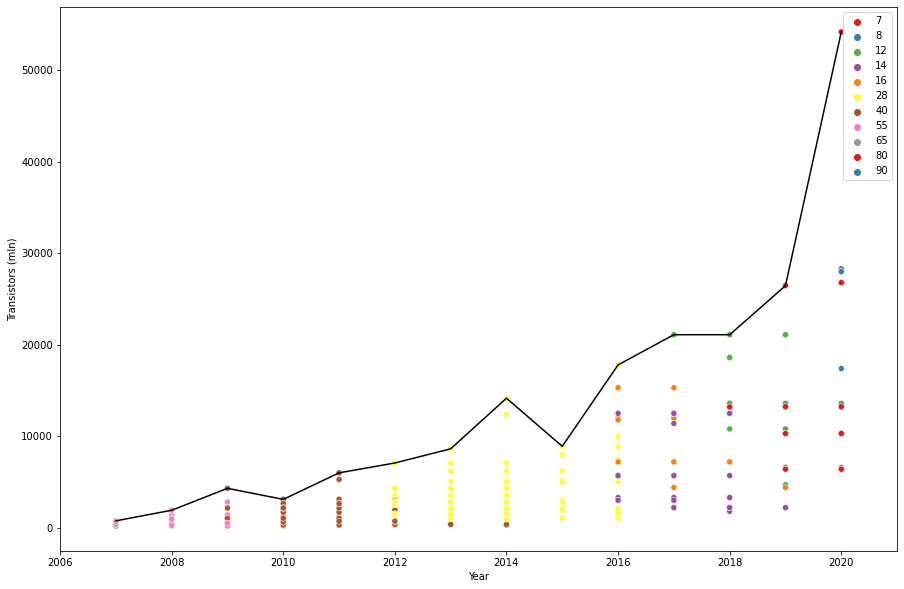

In [3]:
plt.figure(figsize=(15, 10))
ax = sns.scatterplot(x='Year',
                     y='Transistors (mln)',
                     hue='Fab',
                     legend='full',
                     data=df,
                     palette=sns.color_palette("Set1", n_colors=len(df.Fab.unique())))
max_transistors_per_year = df.groupby('Year')['Transistors (mln)'].max()
sns.lineplot(data=max_transistors_per_year,
             ax=ax.axes,
             color='black')
ax.set_xlim(2006, 2021)
plt.show()

As we could see from the plot above, the Moore's law  (摩尔定律) is true for 2019-2020 years, but over the 2006-2018 years the growth was almost linear.

However, the Moore's law is almost true for the **transistors density**. Look at the plot below and see it doubling every ~3 years.

To display a smoothing function for the number of transistors we'll use `sns.regplot()`. Use `order` parametr to estimate a polynomial regression (多项式回归).

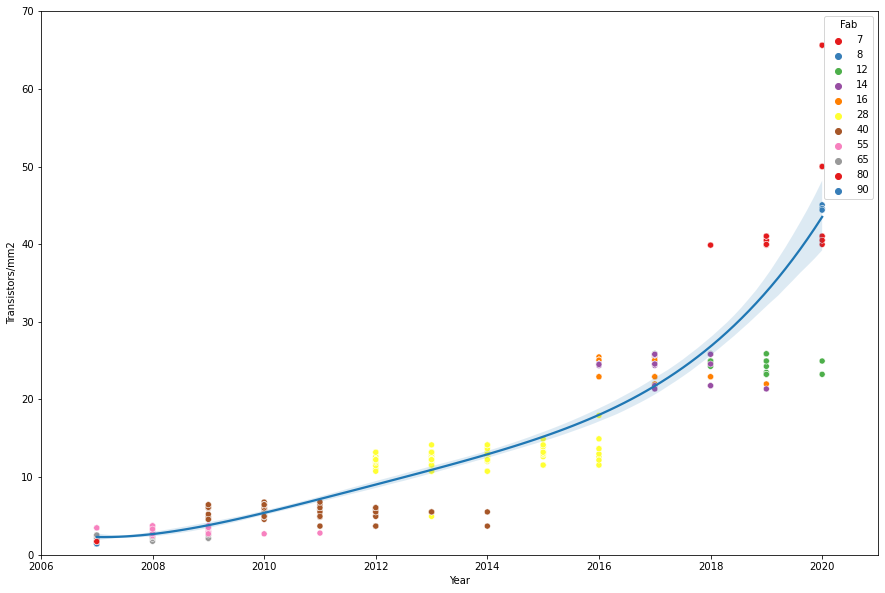

In [4]:
plt.figure(figsize=(15, 10))
df['Transistors/mm2'] = df['Transistors (mln)'] / df['Die size']
ax = sns.scatterplot(x='Year',
                     y='Transistors/mm2',
                     hue='Fab',
                     legend='full',
                     data=df,
                     x_jitter=1000,
                     palette=sns.color_palette("Set1", n_colors=len(df.Fab.unique())))
ax = sns.regplot(x='Year',
                 y='Transistors/mm2',
                 data=df,
                 scatter=False,
                 ax=ax.axes,
                 order=4)
ax.set_xlim(2006, 2021)
ax.set_ylim(0, 70)
plt.show()

# Distplot

Another interesting topic is GPU power consumption and heating.

This dataset splits GPUs into three groups:

* (Desktop) Consumer GPUs, e.g. Nvidia GeForce and AMD Radeon R series
* (Workstation) Workstation GPUs such as Nvidia Quadro and AMD Radeon FirePro
* (Datacenter) Server GPU, e.g. Nvidia P/V/T series and AMD Radeon Instinct

We will use `sns.displot()` to display the distribution of TDP (thermal design power, 热设计功耗) for the 3 GPU groups. This method shows the exact distribution in bins and the smoothing line approximation.

When defining `plt.subplots()` we'll set `sharex=True` to skip displaying the same xlabels across these 3 plots.

`Sns.despine()` removes the top and right spines from plot. If you add `left=True` parameter, the left spine will also be removed.

Note: Do not use `sns.distplot()` as it's deprecated after the recent seaborn update.

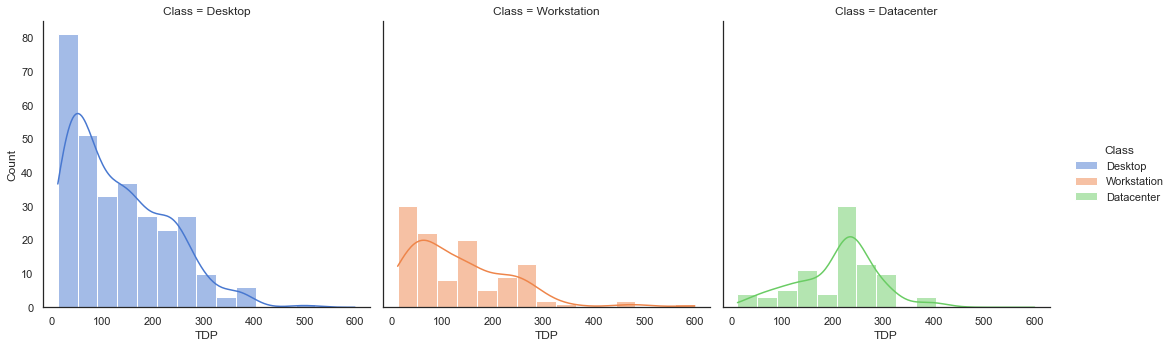

In [5]:
sns.set(style="white", palette="muted", color_codes=True)
sns.displot(data=df, x="TDP", hue="Class", col="Class", kde=True)
plt.show()

While server GPUs (Datacenter) are more hot and powerful on average than consumer (Desktop) and workstation ones, it's interesting that there's a lot of low-power workstation GPUs. These ones are intended not for 3D graphics or parallel computing, but for managing display panels and video walls.

# Violin plot

`sns.violinplot()` helps to see the distribution across several variables. In the next plot we'll see how the distribution changes depending on the Fabrication process (制造工艺) and the TDP (热设计功耗) across two manufacturers (Nvidia and AMD Radeon).

Violin settings:

* `split=True` combines two violin plots
* `bw` is the scale factor to use when computing the kernel bandwidth
* `cut=True` trims each violin
* `linewidth` defines the contour line thickness

Feel free to play with these paremetrs to understand in detail what they do.

<Figure size 1080x720 with 0 Axes>

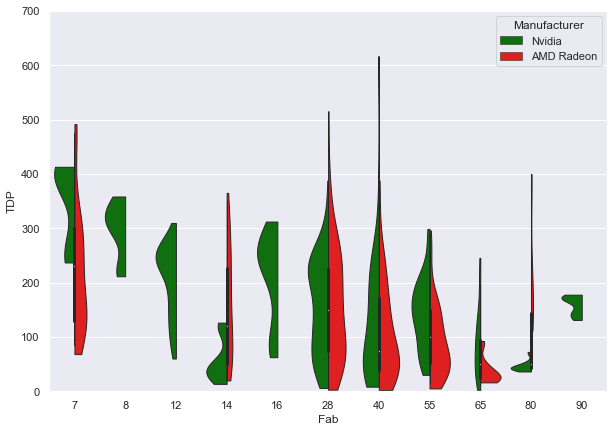

In [6]:
plt.figure(figsize=(15, 10))
sns.set()
_, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(x='Fab', 
               y='TDP', 
               hue='Manufacturer', 
               data=df, 
               split=True, 
               bw=.5, 
               cut=0.3, 
               linewidth=1,
               palette=sns.color_palette(['green', 'red']))
ax.set(ylim=(0, 700))
plt.show()

While there's no some clear correlation regarging manufacturer and chip TDP, it's interesting to see that same could be said regarding fabrication process and TDP.

Although power consumption of transistors gets lower as they become smaller, growing amount of transistors on a chip compensates for this effect.

# Swarm plot

We could split the same data across GPU classes instead of manufacturers.

Use `sns.swarmplot()` to draw a categorical scatterplot with non-overlapping points.

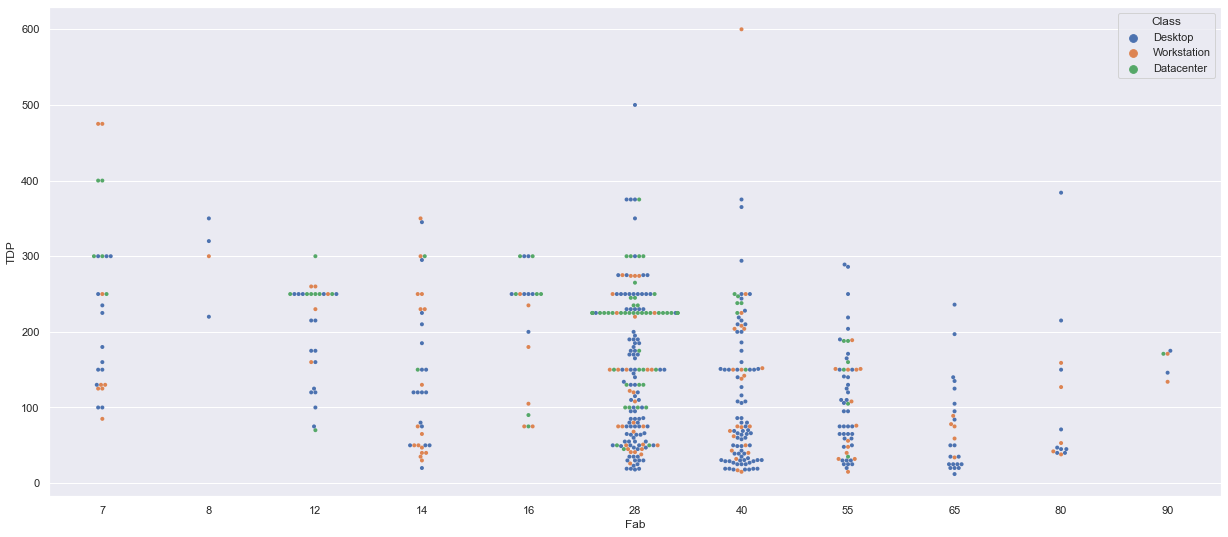

In [7]:
_, ax = plt.subplots(figsize=(21, 9))
sns.swarmplot(x='Fab', y='TDP', hue='Class', data=df, size=4)
plt.show()

# Strip plot and point plot

`sns.stripplot()` helps to draw a scatter plot where one variable is categorical. `dodge=True` separates the points of different classes.

`sns.pointplot()` shows an estimate of **central tendency** for the distribution.

Let's display the TDP distribution across classes and manufacturers, disregard of fabrication process level.

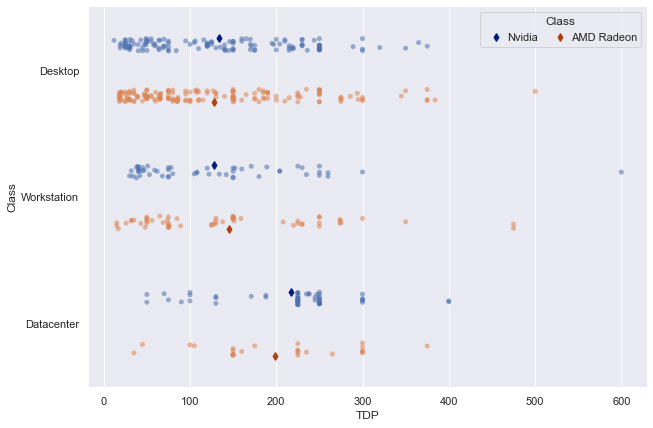

In [8]:
_, ax = plt.subplots(figsize=(10, 7))
sns.despine(bottom=True, left=True)

sns.stripplot(x="TDP", y="Class", hue="Manufacturer",
              data=df, dodge=.5, alpha=.55, zorder=1)

sns.pointplot(x="TDP", y="Class", hue="Manufacturer",
              data=df, dodge=.5, join=False, palette="dark",
              markers="d", scale=.75, ci=None)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[2:], labels[2:], title="Class",
          handletextpad=0, columnspacing=1,
          loc="best", ncol=2, frameon=True)

# Lm plot

`sns.lmplot()` helps to print the data and its regression model fit in one plot. Set the `col` parameter to seperate the visualizations across the classes. `col_wrap` defines how many colums will be displayed in one row.

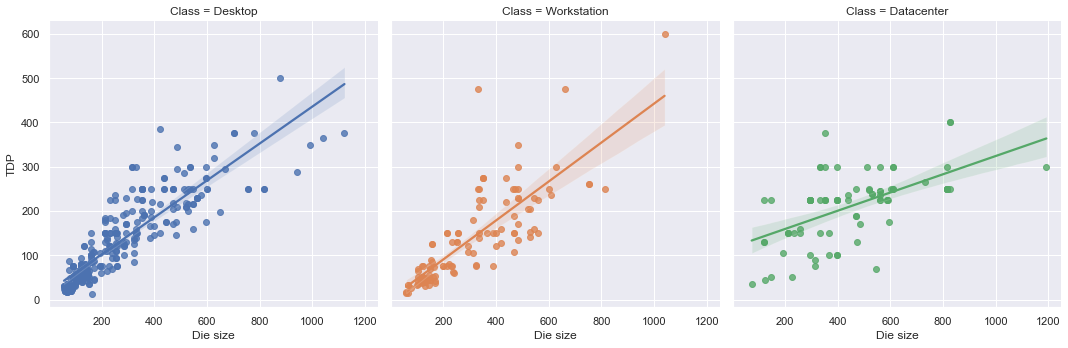

In [9]:
sns.lmplot(x='Die size', y='TDP', data=df, hue='Class', col='Class', col_wrap=3)
plt.tight_layout()

From the plots above we can see a linear correlation of TDP and the physical amount of silicon, including die size (管芯尺寸).

# Reg plot

A combination of `sns.lmplot()` with `fit_reg=False` and `sns.regplot()` produces a scatter plot with one regression approximation line.

When we use `hue="Fab"` seperation and `fit_reg=True` in lmplot, it will produce a regression line for every class, but in our case we need the general approximation line.

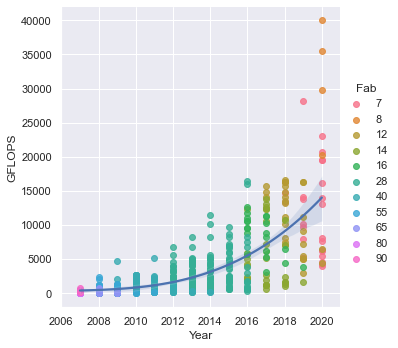

In [10]:
ax = sns.lmplot(x='Year', y='GFLOPS', data=df, hue='Fab', fit_reg=False)
ax.axes[0, 0].set_xlim((2006, 2021))
sns.regplot(x='Year', y='GFLOPS', data=df, scatter=False, ax=ax.axes[0, 0], order=3)
plt.show()

Let's compute an additional feature: the number of GFLOPS (每秒10亿次的浮点运算数)  per million of transistors:

In [11]:
df['GFLOPS/transistors'] = df['GFLOPS'] / df['Transistors (mln)']
df

,Manufacturer,Class,Name,Year,Fab,Transistors (mln),Die size,Memory size,Memory speed,GFLOPS,TDP,Transistors/mm2,GFLOPS/transistors
0,Nvidia,Desktop,GeForce 8300 GS,2007,80,210,127,512,6.4,14.4,40.0,1.653543,0.068571
1,Nvidia,Desktop,GeForce 8400 GS,2007,80,210,127,512,6.4,28.8,40.0,1.653543,0.137143
2,Nvidia,Desktop,GeForce 8400 GS rev.2,2007,65,210,86,512,6.4,24.4,25.0,2.441860,0.116190
3,Nvidia,Desktop,GeForce 8400 GS rev.3,2010,40,260,57,1024,9.6,19.7,25.0,4.561404,0.075769
4,Nvidia,Desktop,GeForce 8500 GT,2007,80,210,127,1024,12.8,28.8,45.0,1.653543,0.137143
...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,AMD Radeon,Datacenter,Radeon Instinct MI6,2016,14,5700,232,16384,224.0,5800.0,150.0,24.568966,1.017544
491,AMD Radeon,Datacenter,Radeon Instinct MI8,2016,28,8900,596,4096,512.0,8200.0,175.0,14.932886,0.921348
492,AMD Radeon,Datacenter,Radeon Instinct MI25,2016,14,12500,510,16384,436.2,12300.0,300.0,24.509804,0.984000
493,AMD Radeon,Datacenter,Radeon Instinct MI50,2018,7,13200,331,16384,1024.0,13400.0,300.0,39.879154,1.015152


# Pair grid

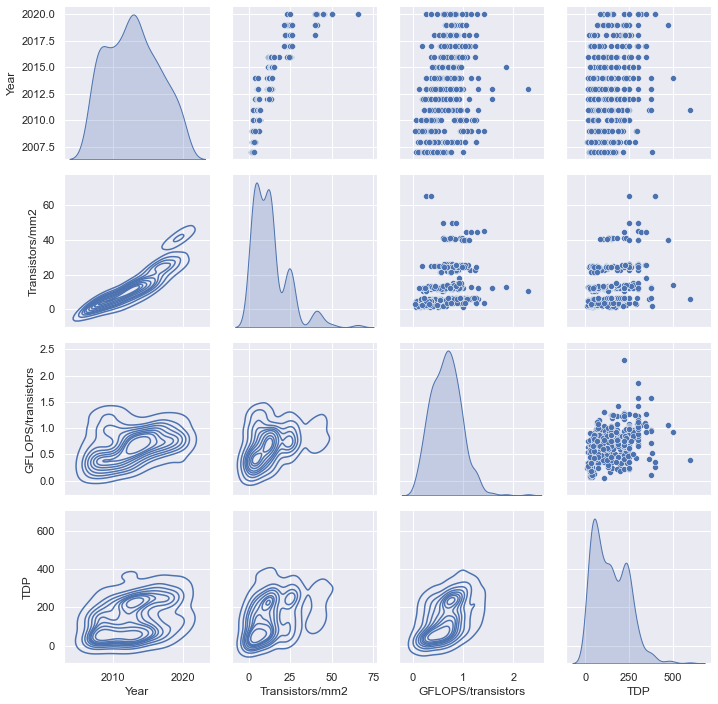

In [12]:
ax = sns.PairGrid(df[['Year', 'Transistors/mm2', 'GFLOPS/transistors', 'TDP']], 
                 diag_sharey=False)
ax.map_upper(sns.scatterplot) # upper: scatter plot
ax.map_lower(sns.kdeplot, colors="C0") # lower: kde  (kernel density estimation, 核密度估计) plot
ax.map_diag(sns.kdeplot, lw=1, shade=True) # diagonal (对角线) : kde plot
plt.show()

The reason for the spike (尖峰) around 250 W TDP is caused by popularity of this value among both AMD and Nvidia's top-tier-chips. 

# Cat plot

`sns.catplot()` allows to display the relation between **categorical** and **numerical** features.

`aspect` parameter is the width-height ratio (i.e., aspect ratio 宽高比) of each facet.
`height` parameter is the height of the facet and `aspect×height` equals the width of each facet. `kind="point"` displays the confidence intervals.
`capsize` is the width of the “caps” on error bars.

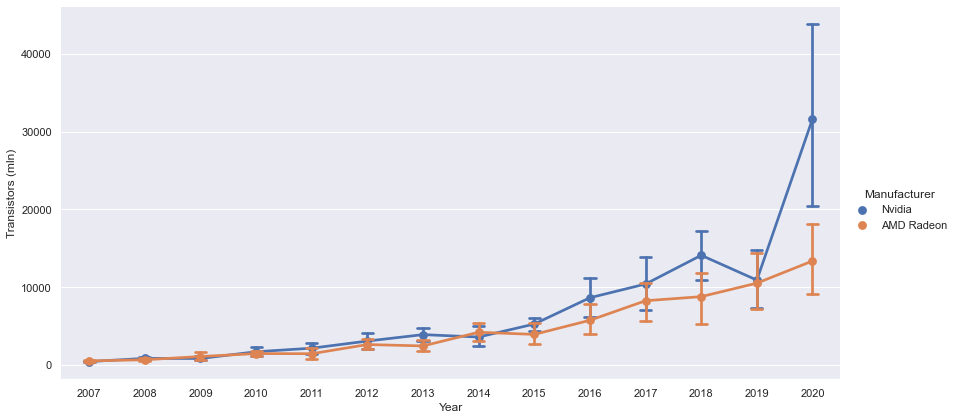

In [13]:
ax = sns.catplot(x="Year", y="Transistors (mln)", hue="Manufacturer",aspect=2, height = 6,
                 capsize=.2, kind="point", data=df)
ax.despine(left=True)
plt.show()

# Joint plot

`sns.jointplot()` displays the scatter plot with the linear approximation on the main plot and additional histograms for x and y axes.

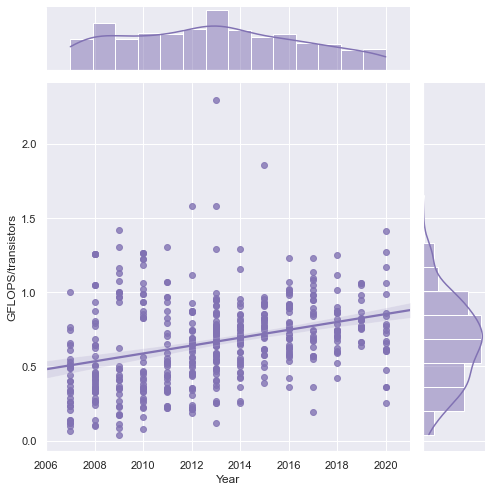

In [14]:
sns.jointplot(x='Year', y='GFLOPS/transistors', data=df,
              kind="reg", truncate=False, marginal_kws={'bins': 14},
              xlim=(2006, 2021),
              color="m", height=7)
plt.show()

# Pair plot

`sns.pairplot()` provides a comprehensive view on our resulting dataframe.

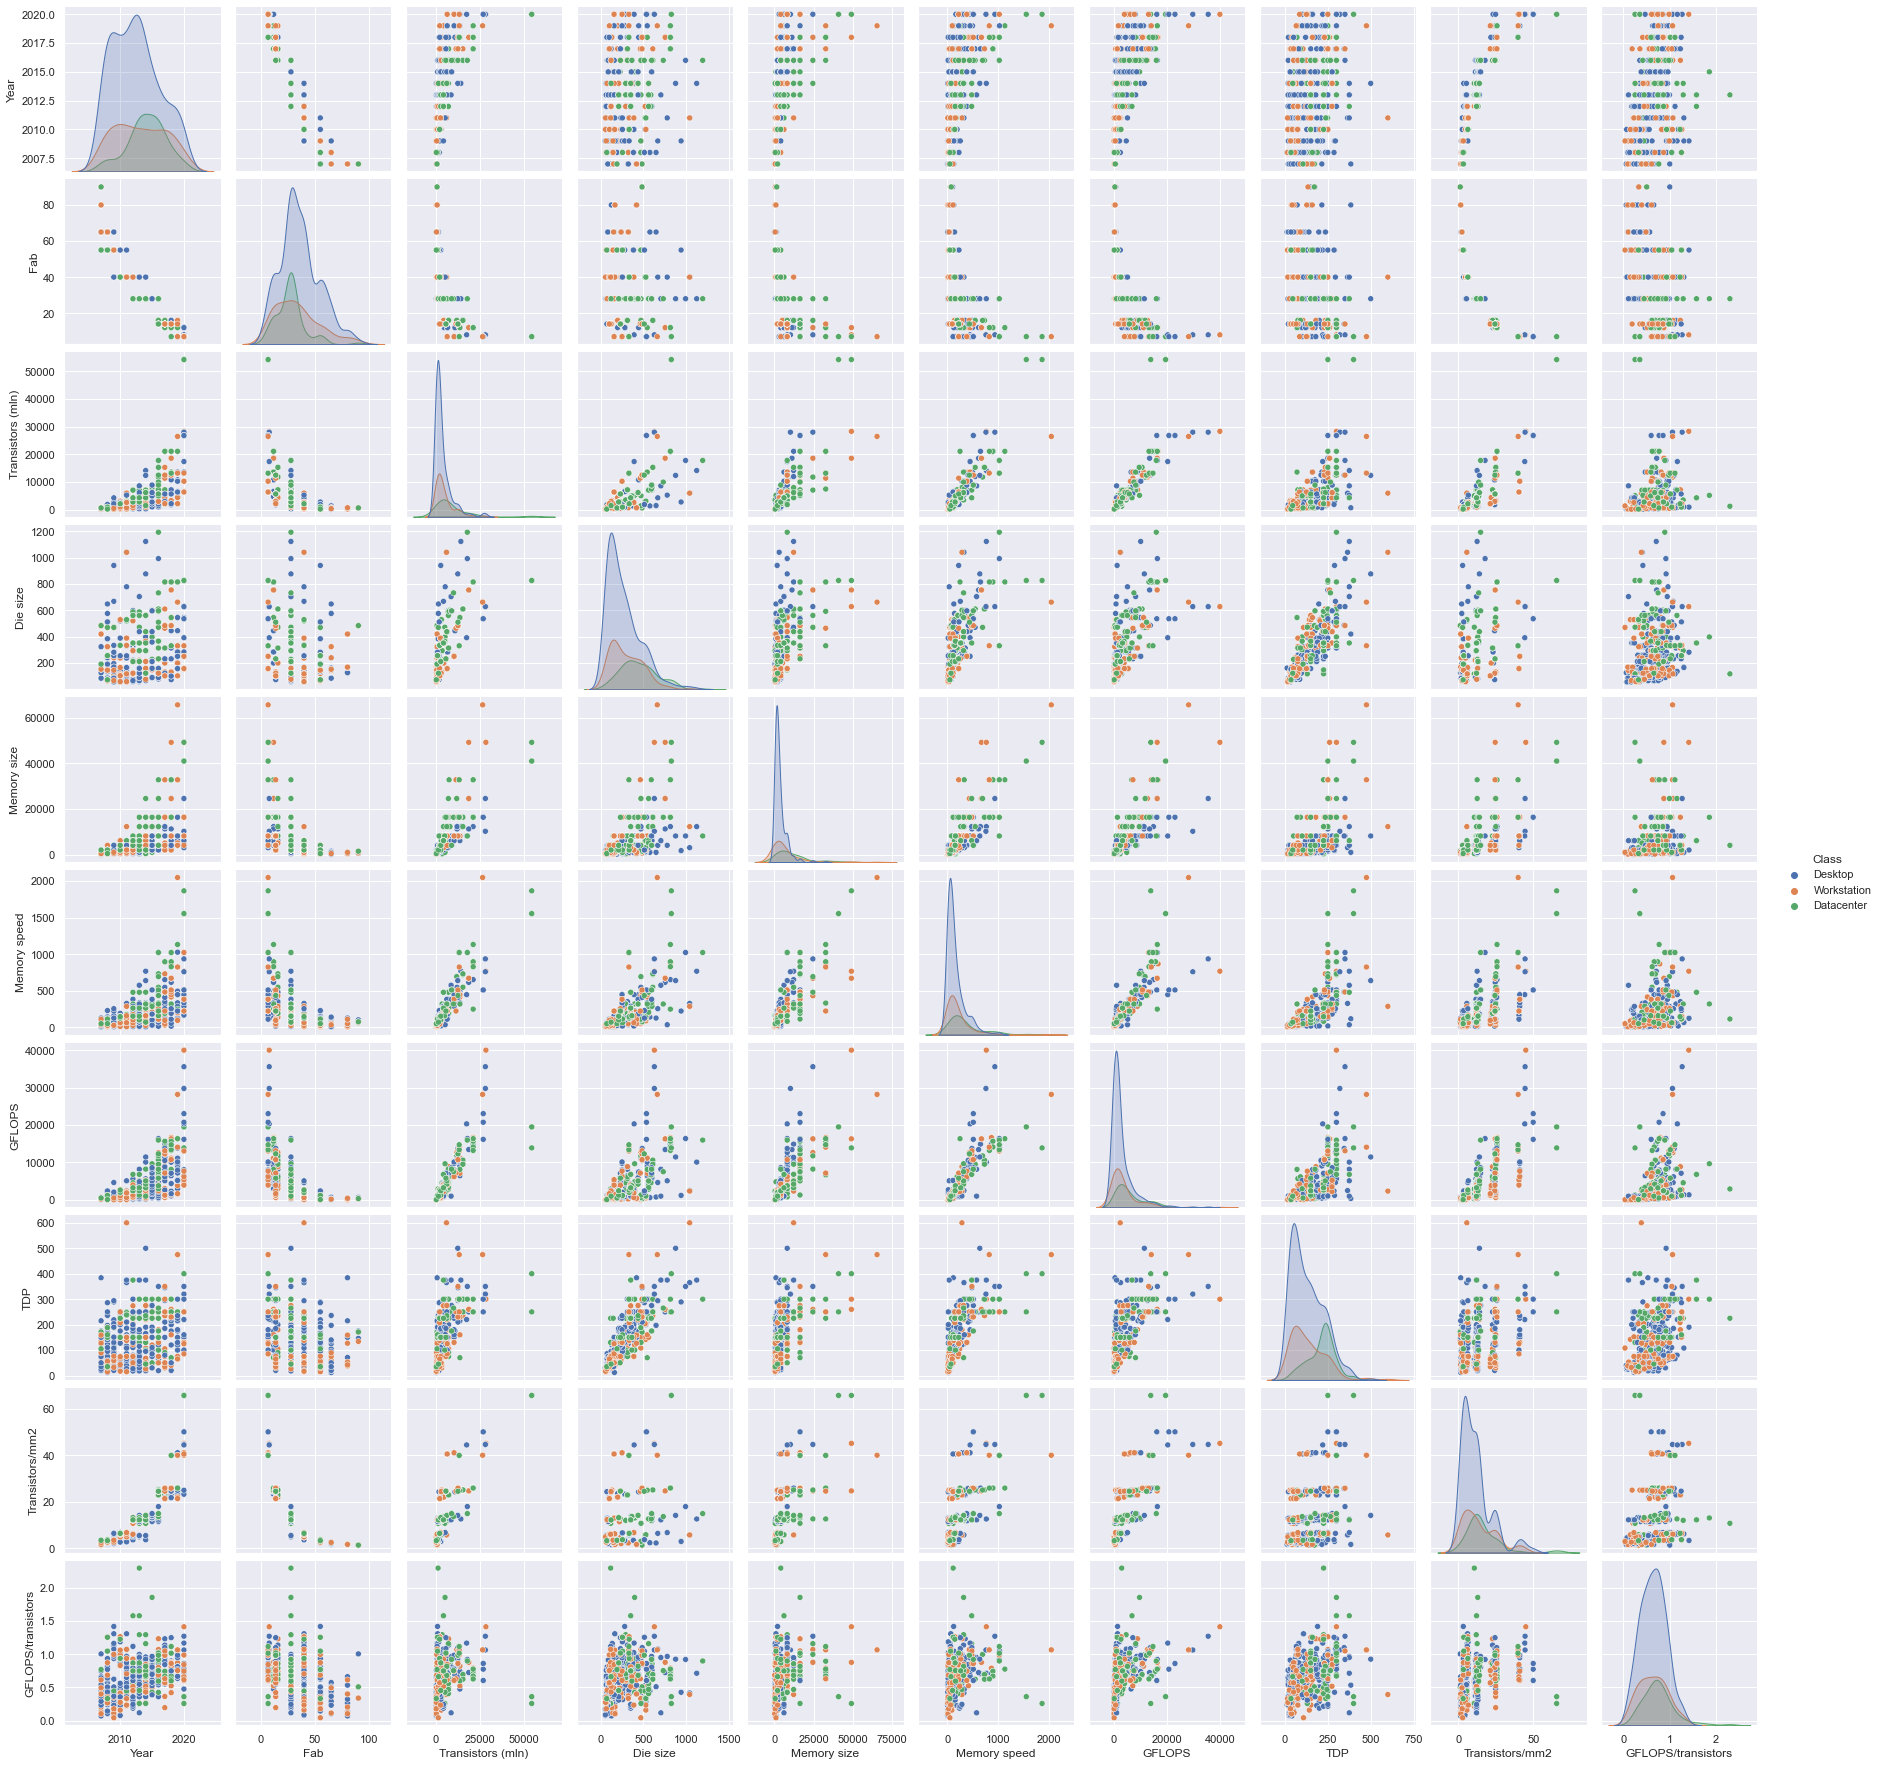

In [15]:
sns.pairplot(df, hue='Class')
plt.show()